In [22]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Agriculture CropYield Dataset
`crop_yield.csv` appears to be a synthetic dataset that we will use to augment the real dataset.

In [23]:
crop_yield = pd.read_csv("../data/raw/crop_yield.csv")

In [24]:
crop_yield.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [25]:
crop_yield["Region"].value_counts()

Region
North    250173
West     250074
South    250054
East     249699
Name: count, dtype: int64

In [26]:
crop_yield["Soil_Type"].value_counts()

Soil_Type
Sandy     167119
Loam      166795
Chalky    166779
Silt      166672
Clay      166352
Peaty     166283
Name: count, dtype: int64

In [27]:
crop_yield.shape

(1000000, 10)

In [28]:
crop_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [29]:
crop_yield.isna().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [30]:
crop_yield.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [31]:
crop_yield_ohe = pd.get_dummies(crop_yield, drop_first=True)
crop_yield_ohe.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region_North,Region_South,Region_West,Soil_Type_Clay,...,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Rainy,Weather_Condition_Sunny
0,897.077239,27.676966,False,True,122,6.555816,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
1,992.673282,18.026142,True,True,140,8.527341,False,True,False,True,...,False,False,False,False,False,True,False,False,True,False
2,147.998025,29.794042,False,False,106,1.127443,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,986.866331,16.644190,False,True,146,6.517573,True,False,False,False,...,False,True,False,False,False,False,True,False,True,False
4,730.379174,31.620687,True,True,110,7.248251,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False


In [32]:
quant_features = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest"]

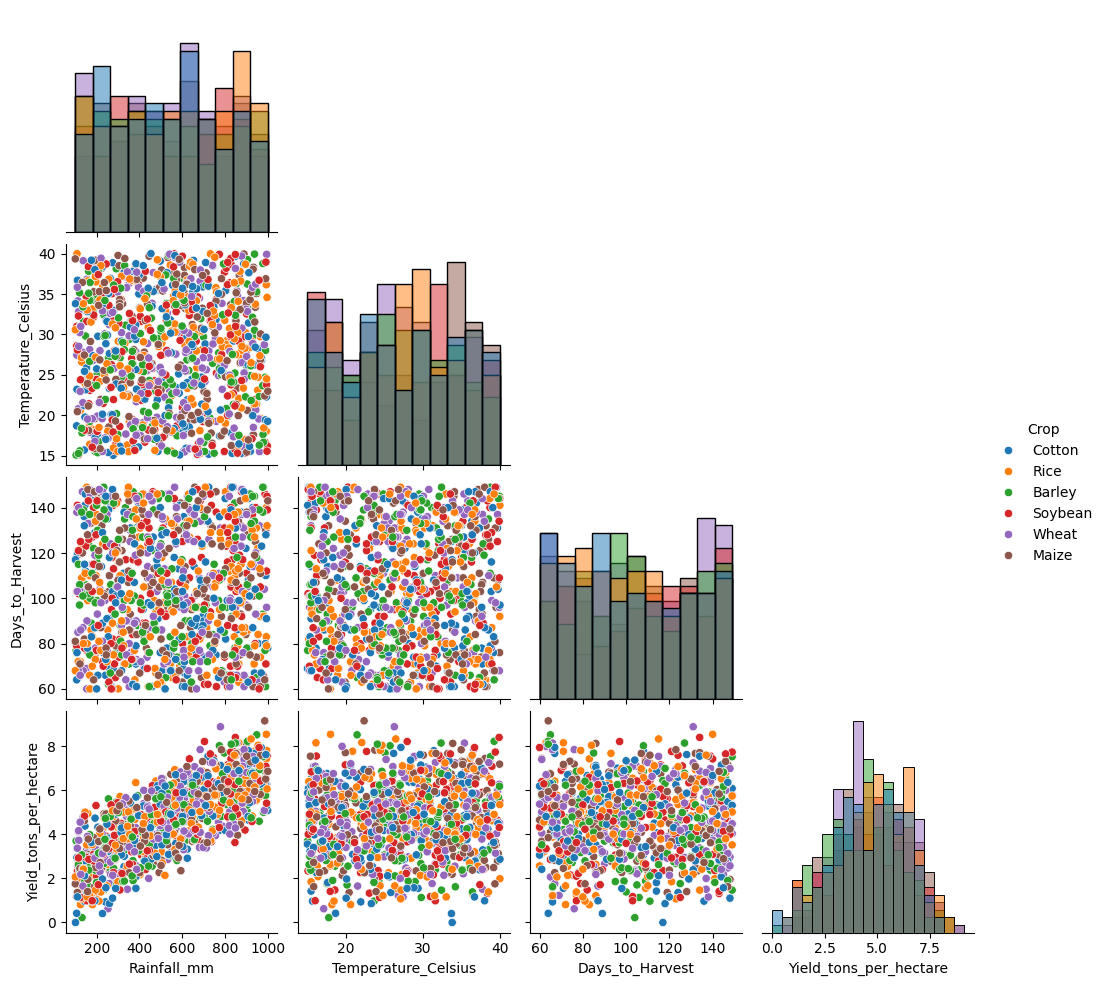

In [33]:
sns.pairplot(crop_yield.loc[:1000, quant_features + ["Yield_tons_per_hectare", "Crop"]], hue="Crop", diag_kind="hist", corner=True)

In [34]:
crop_yield_ohe.columns

Index(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare',
       'Region_North', 'Region_South', 'Region_West', 'Soil_Type_Clay',
       'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice',
       'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Rainy',
       'Weather_Condition_Sunny'],
      dtype='object')

<Axes: xlabel='Rainfall_mm'>

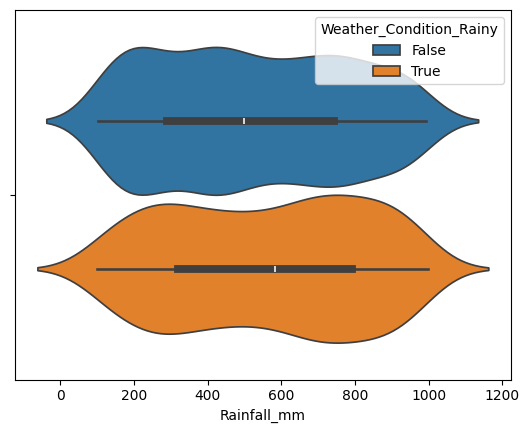

In [35]:
sns.violinplot(x="Rainfall_mm", hue="Weather_Condition_Rainy", data=crop_yield_ohe.sample(1000))

<Axes: xlabel='Temperature_Celsius'>

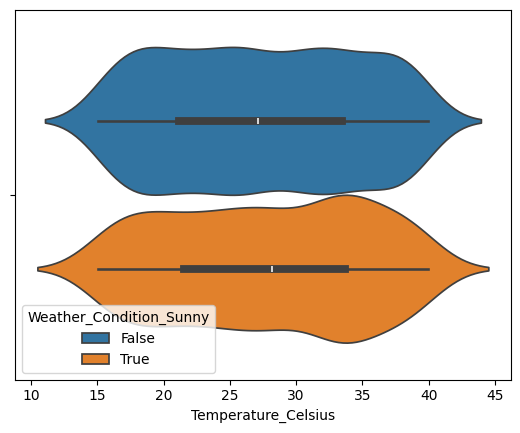

In [36]:
sns.violinplot(x="Temperature_Celsius", hue="Weather_Condition_Sunny", data=crop_yield_ohe.sample(1000))

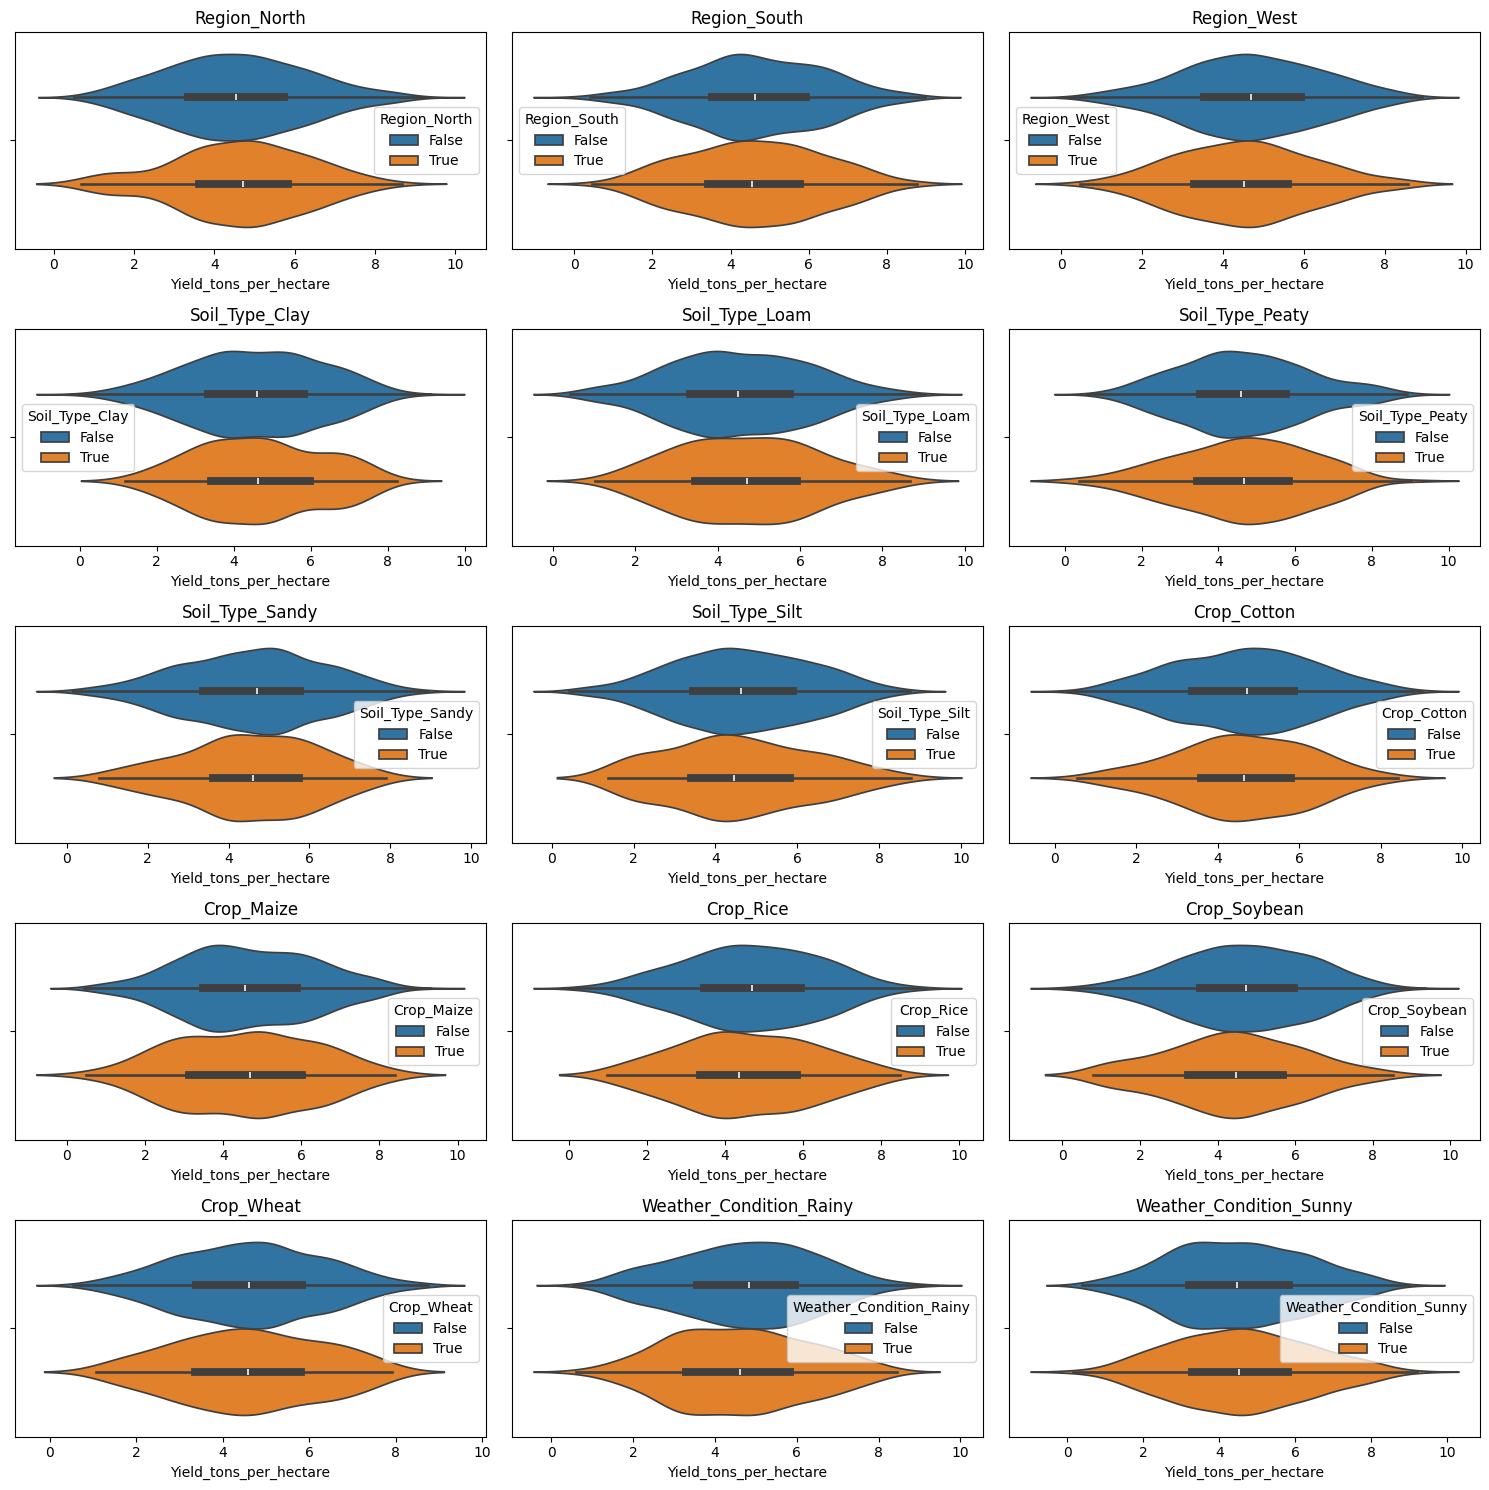

In [37]:
ohe_features = ['Region_North', 'Region_South', 'Region_West', 'Soil_Type_Clay',
       'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice',
       'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Rainy',
       'Weather_Condition_Sunny']
num_features = len(ohe_features)

fig, axs = plt.subplots(num_features // 3, 3, figsize=(15, 15))

for i, feature in enumerate(ohe_features):
    sns.violinplot(x="Yield_tons_per_hectare", hue=feature, data=crop_yield_ohe.sample(1000), ax=axs[i // 3, i % 3])
    axs[i // 3, i % 3].set_title(feature)

plt.tight_layout()

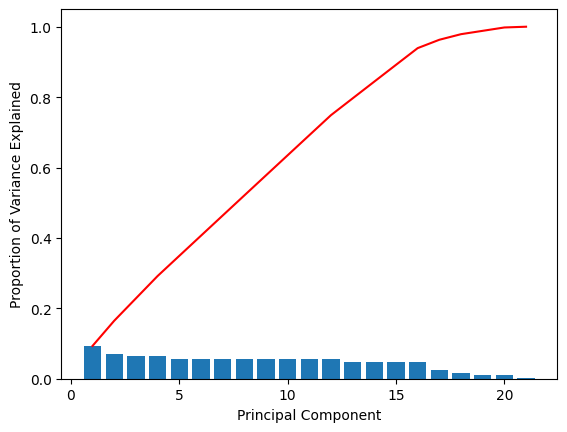

In [38]:
pca = PCA()
s = StandardScaler()
crop_yield_scaled = s.fit_transform(crop_yield_ohe)

pca.fit(crop_yield_scaled)
scree = pca.explained_variance_ratio_
scree_cum = scree.cumsum()

plt.bar(range(1, len(scree) + 1), scree)
plt.plot(range(1, len(scree) + 1), scree_cum, color="red")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.show()

<Axes: >

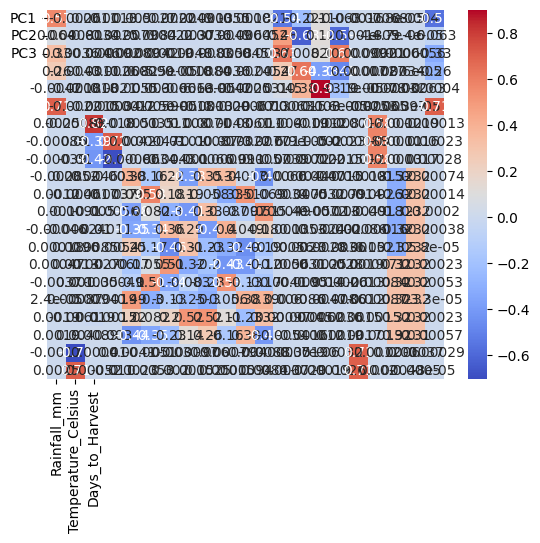

In [39]:
pcs = pca.components_
sns.heatmap(pcs.T, xticklabels=quant_features, yticklabels=["PC1", "PC2", "PC3"], annot=True, cmap="coolwarm")

# CropYield Prediction Dataset

**Pesticides** & **Yield** are collected from FAO.

**Rainfall** & **Avg. Temperature** are collected from World Data Bank.

`yield_df.csv` is final dataset processed by cleaning & merging of pesticides, yield, rainfall & avg. temperature. 


In [40]:
yield_df = pd.read_csv("../data/raw/yield_df.csv", index_col=0)
yield_df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [41]:
yield_df.shape

(28242, 7)

In [42]:
yield_df.isna().mean()

Area                             0.0
Item                             0.0
Year                             0.0
hg/ha_yield                      0.0
average_rain_fall_mm_per_year    0.0
pesticides_tonnes                0.0
avg_temp                         0.0
dtype: float64

In [43]:
for p in list(yield_df["Area"].value_counts().index):
    print(p, end=" ")

India Brazil Mexico Pakistan Australia Japan Indonesia South Africa Turkey Ecuador Canada Spain Colombia Argentina Dominican Republic Egypt Morocco Italy Bangladesh Iraq Germany Kazakhstan Cameroon United Kingdom Kenya Chile Uganda Mali Burundi Rwanda Peru Guatemala Honduras Haiti El Salvador Burkina Faso Zambia Madagascar Sri Lanka Zimbabwe Saudi Arabia Nicaragua Malawi Guinea Angola Uruguay Niger Papua New Guinea Greece Mauritania Mozambique Thailand Jamaica Central African Republic Ghana France Suriname Portugal Hungary Romania Senegal Libya Bulgaria Ukraine Tajikistan Guyana Azerbaijan Nepal Algeria Croatia Mauritius Albania Austria Malaysia New Zealand Switzerland Lebanon Lesotho Slovenia Namibia Eritrea Poland Tunisia Netherlands Qatar Bahamas Botswana Armenia Lithuania Belarus Denmark Ireland Finland Sweden Norway Estonia Latvia Belgium Bahrain Sudan Montenegro 

In [44]:
yield_df["Item"].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

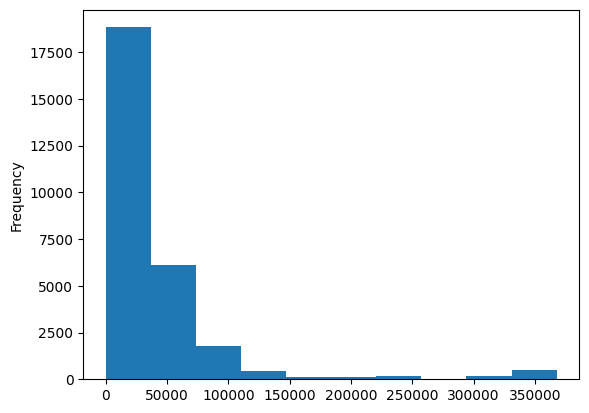

In [45]:
yield_df["pesticides_tonnes"].plot.hist()

In [46]:
quant_features_yield = ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]

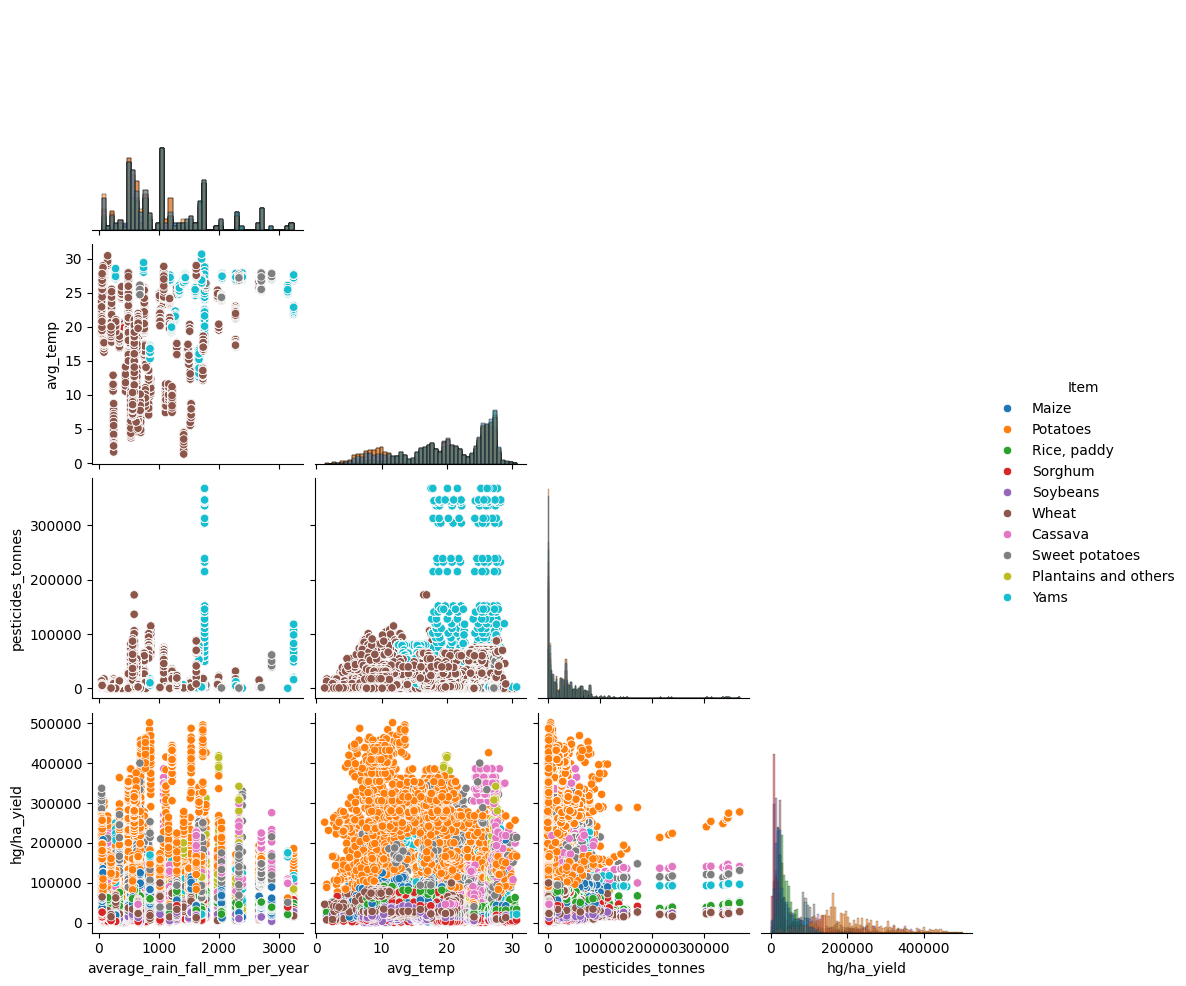

In [47]:
sns.pairplot(yield_df.loc[:, quant_features_yield + ["hg/ha_yield", "Item"]], hue="Item", diag_kind="hist", corner=True)

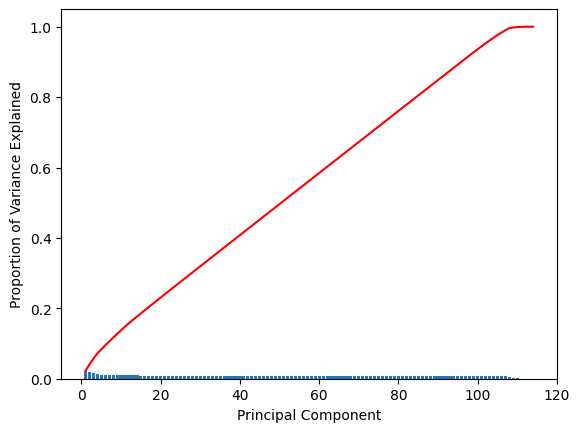

In [48]:
pca_yield = PCA()
s = StandardScaler()
yield_df_scaled = s.fit_transform(pd.get_dummies(yield_df, drop_first=True))

pca_yield.fit(yield_df_scaled)
scree_yield = pca_yield.explained_variance_ratio_
scree_cum_yield = scree_yield.cumsum()

plt.bar(range(1, len(scree_yield) + 1), scree_yield)
plt.plot(range(1, len(scree_yield) + 1), scree_cum_yield, color="red")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.show()

<Axes: >

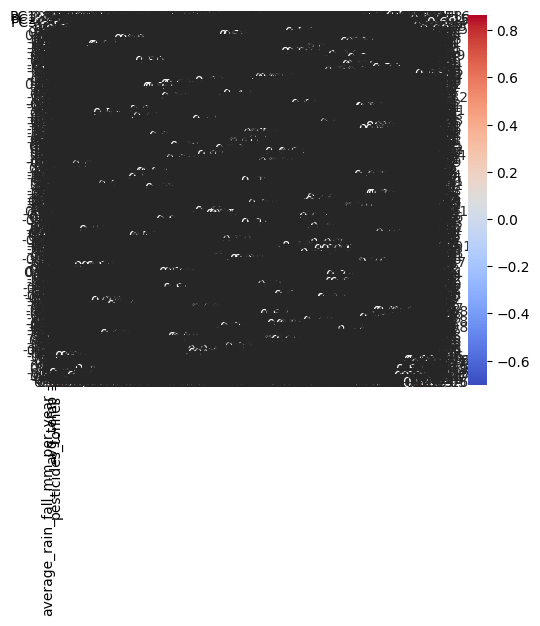

In [49]:
pcs_yield = pca_yield.components_
sns.heatmap(pcs_yield.T, xticklabels=quant_features_yield, yticklabels=["PC1", "PC2", "PC3"], annot=True, cmap="coolwarm")

# Merging

**Complete correspondance:**
- Rainfall_mm *and* average_rain_fall_mm_per_year 
- Temperature_Celsius *and* avg_temp

**Correspondance with slight changes:**
- Crop *and* Item
- Yield_tons_per_hectare *and* hg/ha_yield
- Region + Soil_type *and* Area

**No correspondance:**
- Days_to_Harvest, Weather_Condition **(not linked to rainfall_mm and temp...)**, Irrigation_Used, Fertilizer_Used
- Year, pesticides_tonnes

<Axes: ylabel='Frequency'>

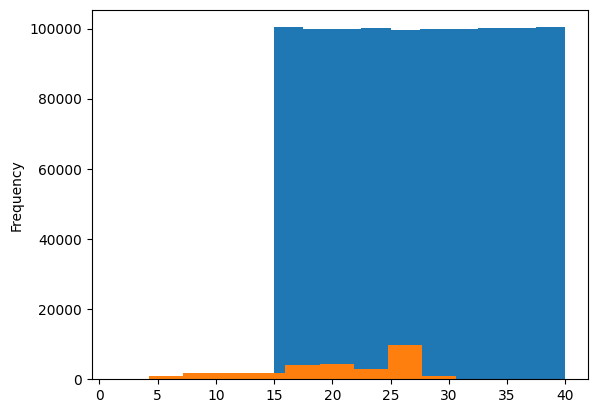

In [50]:
crop_yield["rain (mm)"] = crop_yield["Rainfall_mm"]
crop_yield["temp (C)"] = crop_yield["Temperature_Celsius"]
crop_yield["item"] = crop_yield["Crop"]

yield_df["rain (mm)"] = yield_df["average_rain_fall_mm_per_year"]
yield_df["temp (C)"] = yield_df["avg_temp"]
yield_df["item"] = yield_df["Item"]

crop_yield["temp (C)"].plot.hist()
yield_df["temp (C)"].plot.hist()

In [51]:
print(crop_yield["item"].value_counts())
print(yield_df["item"].value_counts())

item
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64
item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64


In [52]:
yield_df["synthetic"] = True
crop_yield["synthetic"] = False

In [53]:
yield_df["item"] = yield_df["item"].replace("Rice, paddy", "Rice")
yield_df["item"] = yield_df["item"].replace("Soybeans", "Soybean")

print(pd.concat([crop_yield["Crop"], yield_df["item"]]).value_counts())

Maize                   170945
Wheat                   170530
Rice                    170180
Soybean                 169572
Barley                  166777
Cotton                  166585
Potatoes                  4276
Sorghum                   3039
Sweet potatoes            2890
Cassava                   2045
Yams                       847
Plantains and others       556
Name: count, dtype: int64


<Axes: ylabel='Frequency'>

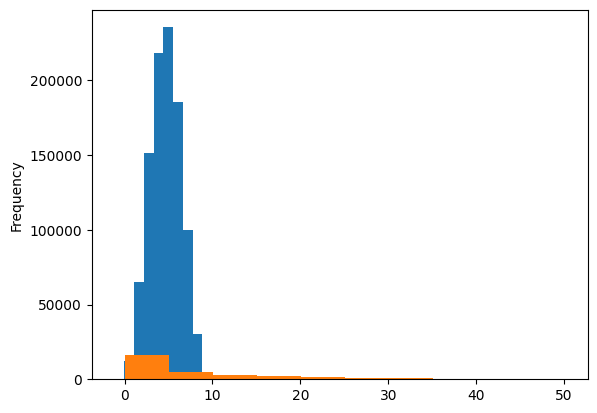

In [54]:
yield_df["yield (t/ha)"] = yield_df["hg/ha_yield"] / 10000
crop_yield["yield (t/ha)"] = crop_yield["Yield_tons_per_hectare"]

crop_yield["yield (t/ha)"].plot.hist()
yield_df["yield (t/ha)"].plot.hist()

In [55]:
country_direction_soil = {
    "India": ["East", "Clay"],
    "Brazil": ["South", "Loam"],
    "Mexico": ["West", "Silt"],
    "Pakistan": ["East", "Sandy"],
    "Australia": ["East", "Sandy"],
    "Japan": ["East", "Loam"],
    "Indonesia": ["East", "Peaty"],
    "South Africa": ["South", "Sandy"],
    "Turkey": ["East", "Loam"],
    "Ecuador": ["West", "Loam"],
    "Canada": ["West", "Loam"],
    "Spain": ["South", "Clay"],
    "Colombia": ["West", "Loam"],
    "Argentina": ["South", "Loam"],
    "Dominican Republic": ["West", "Clay"],
    "Egypt": ["East", "Sandy"],
    "Italy": ["South", "Loam"],
    "Morocco": ["South", "Sandy"],
    "Bangladesh": ["East", "Silt"],
    "Iraq": ["East", "Sandy"],
    "Germany": ["North", "Loam"],
    "Kazakhstan": ["East", "Clay"],
    "Cameroon": ["South", "Loam"],
    "Chile": ["South", "Loam"],
    "Kenya": ["East", "Clay"],
    "United Kingdom": ["North", "Loam"],
    "Burundi": ["East", "Clay"],
    "Mali": ["South", "Sandy"],
    "Peru": ["West", "Silt"],
    "Rwanda": ["East", "Clay"],
    "Uganda": ["East", "Clay"],
    "Guatemala": ["West", "Loam"],
    "Honduras": ["West", "Clay"],
    "Burkina Faso": ["South", "Sandy"],
    "El Salvador": ["West", "Loam"],
    "Haiti": ["West", "Clay"],
    "Madagascar": ["East", "Sandy"],
    "Saudi Arabia": ["East", "Sandy"],
    "Sri Lanka": ["East", "Clay"],
    "Zambia": ["South", "Sandy"],
    "Zimbabwe": ["South", "Clay"],
    "Nicaragua": ["West", "Loam"],
    "Guinea": ["South", "Loam"],
    "Malawi": ["East", "Clay"],
    "Angola": ["South", "Sandy"],
    "Central African Republic": ["South", "Sandy"],
    "Greece": ["East", "Loam"],
    "Jamaica": ["West", "Loam"],
    "Mauritania": ["South", "Sandy"],
    "Mozambique": ["East", "Sandy"],
    "Niger": ["South", "Sandy"],
    "Papua New Guinea": ["East", "Peaty"],
    "Thailand": ["East", "Clay"],
    "Uruguay": ["South", "Loam"],
    "Ghana": ["South", "Loam"],
    "Bulgaria": ["East", "Loam"],
    "France": ["Central", "Loam"],
    "Hungary": ["East", "Loam"],
    "Libya": ["South", "Sandy"],
    "Portugal": ["South", "Sandy"],
    "Romania": ["East", "Loam"],
    "Senegal": ["South", "Sandy"],
    "Suriname": ["South", "Peaty"],
    "Ukraine": ["East", "Chalky"],
    "Tajikistan": ["East", "Loam"],
    "Guyana": ["South", "Peaty"],
    "Azerbaijan": ["East", "Loam"],
    "Nepal": ["East", "Loam"],
    "Algeria": ["South", "Sandy"],
    "Croatia": ["East", "Loam"],
    "Mauritius": ["East", "Loam"],
    "Albania": ["East", "Loam"],
    "Austria": ["East", "Loam"],
    "Malaysia": ["East", "Peaty"],
    "Lebanon": ["East", "Loam"],
    "Lesotho": ["South", "Clay"],
    "New Zealand": ["East", "Loam"],
    "Switzerland": ["Central", "Loam"],
    "Slovenia": ["East", "Loam"],
    "Namibia": ["South", "Sandy"],
    "Eritrea": ["East", "Sandy"],
    "Poland": ["East", "Loam"],
    "Netherlands": ["North", "Peaty"],
    "Qatar": ["East", "Sandy"],
    "Tunisia": ["South", "Sandy"],
    "Bahamas": ["West", "Sandy"],
    "Botswana": ["South", "Sandy"],
    "Armenia": ["East", "Loam"],
    "Belarus": ["East", "Loam"],
    "Lithuania": ["North", "Loam"],
    "Denmark": ["North", "Loam"],
    "Finland": ["North", "Peaty"],
    "Ireland": ["North", "Peaty"],
    "Norway": ["North", "Loam"],
    "Sweden": ["North", "Loam"],
    "Estonia": ["North", "Loam"],
    "Latvia": ["North", "Loam"],
    "Belgium": ["North", "Loam"],
    "Bahrain": ["East", "Sandy"],
    "Sudan": ["East", "Sandy"],
    "Montenegro": ["East", "Loam"]
}

In [56]:
yield_df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'rain (mm)', 'temp (C)', 'item',
       'synthetic', 'yield (t/ha)'],
      dtype='object')

In [57]:
yield_df["direction"] = yield_df["Area"].map(lambda x: country_direction_soil[x][0])
crop_yield["direction"] = crop_yield["Region"]
yield_df["soil"] = yield_df["Area"].map(lambda x: country_direction_soil[x][1])
crop_yield["soil"] = crop_yield["Soil_Type"]

In [58]:
final_columns = ["yield (t/ha)", "direction", "soil", "item", "rain (mm)", "temp (C)", "synthetic"]

merged_df = pd.concat([crop_yield[final_columns], yield_df[final_columns]], axis=0).reset_index(drop=True)
merged_df.head()

,yield (t/ha),direction,soil,item,rain (mm),temp (C),synthetic
0,6.555816,West,Sandy,Cotton,897.077239,27.676966,False
1,8.527341,South,Clay,Rice,992.673282,18.026142,False
2,1.127443,North,Loam,Barley,147.998025,29.794042,False
3,6.517573,North,Sandy,Soybean,986.866331,16.644190,False
4,7.248251,South,Silt,Wheat,730.379174,31.620687,False


In [59]:
merged_df.to_csv("../data/processed/merged_df.csv", index=False)

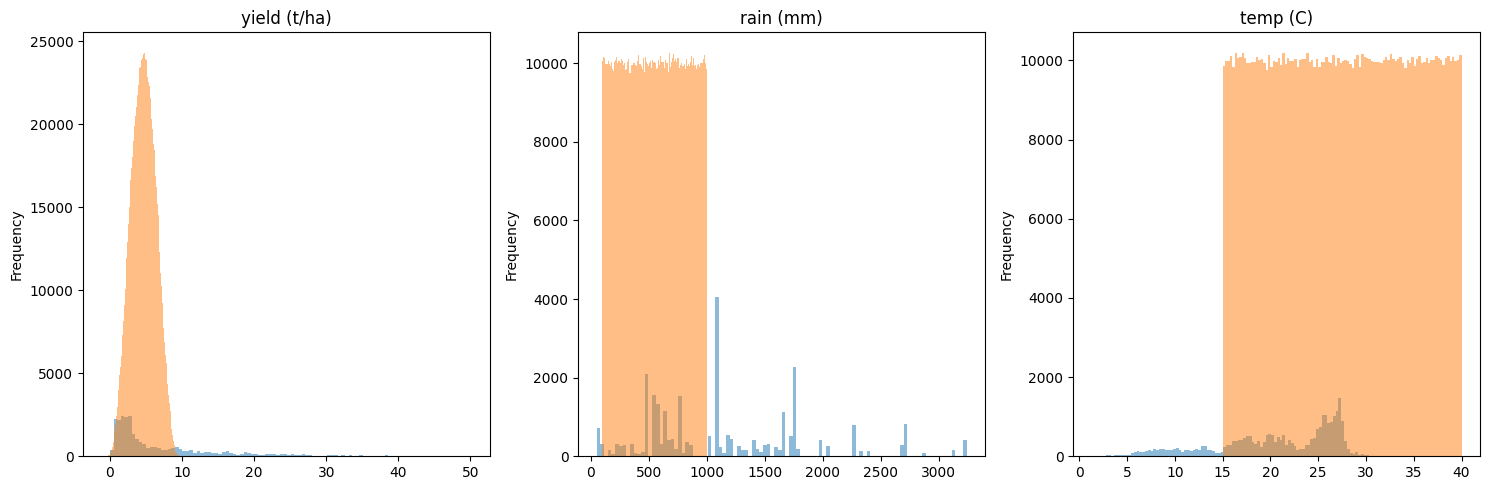

In [60]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, c in enumerate(["yield (t/ha)", "rain (mm)", "temp (C)"]):
    yield_df[c].plot.hist(ax=axs[i], bins=100, title=c, alpha=0.5)
    crop_yield[c].plot.hist(ax=axs[i], bins=100, title=c, alpha=0.5)

plt.tight_layout()

In [61]:
yield_df[["Area", "Item", "temp (C)", "rain (mm)", "yield (t/ha)", "Year", "pesticides_tonnes"]].to_csv("../data/processed/yield_df.csv", index=False)

In [62]:
merged_df.head()

,yield (t/ha),direction,soil,item,rain (mm),temp (C),synthetic
0,6.555816,West,Sandy,Cotton,897.077239,27.676966,False
1,8.527341,South,Clay,Rice,992.673282,18.026142,False
2,1.127443,North,Loam,Barley,147.998025,29.794042,False
3,6.517573,North,Sandy,Soybean,986.866331,16.644190,False
4,7.248251,South,Silt,Wheat,730.379174,31.620687,False


In [63]:
merged_df[abs(merged_df["rain (mm)"] - 897) <= 0.01]

,yield (t/ha),direction,soil,item,rain (mm),temp (C),synthetic
5325,5.831590,North,Chalky,Rice,897.007714,15.075636,False
111082,7.284977,South,Peaty,Cotton,896.990356,38.172247,False
210816,6.396692,West,Peaty,Cotton,897.006186,17.500981,False
242038,5.159876,South,Sandy,Cotton,897.000149,27.710696,False
410849,7.273371,North,Peaty,Barley,896.997805,35.780070,False
425003,7.825390,West,Peaty,Wheat,897.007229,38.516726,False
430200,5.438637,East,Sandy,Wheat,897.004740,17.703917,False
483625,7.343219,North,Clay,Rice,897.006740,17.542186,False
488400,8.910562,West,Chalky,Wheat,897.008266,24.172877,False
489423,6.180216,North,Clay,Soybean,897.008452,16.261162,False


# Merging via KNN

In [64]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np

In [65]:
def get_nearest_crop_neighbors(df_real, df_synthetic, crop_name, features):
    """
    Finds the nearest synthetic neighbor for each real data point, 
    filtered by a specific crop type.
    """
    # 1. Filter by crop
    real_sub = df_real[df_real['item'] == crop_name].copy()
    if real_sub.empty:
        raise ValueError(f"No data found for crop: {crop_name} in real dataset.")
    
    synth_sub = df_synthetic[df_synthetic['item'] == crop_name].copy()    
    if synth_sub.empty:
        raise ValueError(f"No data found for crop: {crop_name} in synthetic dataset.")

    # 2. Scaling is mandatory for KNN
    scaler = StandardScaler()
    synth_scaled = scaler.fit_transform(synth_sub[features])
    real_scaled = scaler.transform(real_sub[features])

    # 3. Fit KNN
    nn = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(synth_scaled)
    distances, indices = nn.kneighbors(real_scaled)

    # 4. Map the results back
    # We use .iloc because 'indices' refers to the position in the filtered synth_sub
    matched_synth_data = synth_sub.iloc[indices.flatten()].reset_index(drop=True)
    
    # Combine real data with its closest synthetic match
    result = real_sub.reset_index(drop=True).join(
        matched_synth_data, 
        rsuffix='_synth'
    )
    result['match_distance'] = distances.flatten()
    
    return result

In [66]:
common_cols =["yield (t/ha)", "rain (mm)", "temp (C)"]

# Example for 'Maize'
maize_matches = get_nearest_crop_neighbors(yield_df, crop_yield, "Maize", common_cols)
maize_matches.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,rain (mm),temp (C),item,...,Days_to_Harvest,Yield_tons_per_hectare,rain (mm)_synth,temp (C)_synth,item_synth,synthetic_synth,yield (t/ha)_synth,direction_synth,soil_synth,match_distance
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,1485.0,16.37,Maize,...,72,4.191078,997.405978,17.471662,Maize,False,4.191078,West,Silt,1.907999
1,Albania,Maize,1991,29068,1485.0,121.0,15.36,1485.0,15.36,Maize,...,126,3.854448,984.931082,17.369398,Maize,False,3.854448,West,Chalky,2.022794
2,Albania,Maize,1992,24876,1485.0,121.0,16.06,1485.0,16.06,Maize,...,126,3.854448,984.931082,17.369398,Maize,False,3.854448,West,Chalky,2.093896
3,Albania,Maize,1993,24185,1485.0,121.0,16.05,1485.0,16.05,Maize,...,126,3.854448,984.931082,17.369398,Maize,False,3.854448,West,Chalky,2.110032
4,Albania,Maize,1994,25848,1485.0,201.0,16.96,1485.0,16.96,Maize,...,126,3.854448,984.931082,17.369398,Maize,False,3.854448,West,Chalky,2.065336


In [67]:
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import HTML
import base64
from io import BytesIO

def generate_pertinence_report(df_real, df_synth, real_cols, synth_cols, crop_col_real='item', crop_col_synth='item', threshold_std=1.0):
    report_data = []

    # Get common crops found in both datasets
    common_crops = set(df_real[crop_col_real]).intersection(set(df_synth[crop_col_synth]))

    for crop in common_crops:
        # 1. Filter data
        r_sub = df_real[df_real[crop_col_real] == crop].copy()
        s_sub = df_synth[df_synth[crop_col_synth] == crop].copy()

        if len(r_sub) < 2 or len(s_sub) < 2:
            continue

        # 2. Scale Features (Mandatory for distance metrics)
        scaler = StandardScaler()
        s_scaled = scaler.fit_transform(s_sub[synth_cols])
        r_scaled = scaler.transform(r_sub[real_cols])

        # 3. Calculate Wasserstein Distance for each feature
        wass_distances = {}
        for i in range(len(real_cols)):
            wd = wasserstein_distance(r_scaled[:, i], s_scaled[:, i])
            wass_distances[real_cols[i]] = wd

        # Generate and save the barplot
        plt.figure(figsize=(10, 6))
        plt.bar(wass_distances.keys(), wass_distances.values(), color='skyblue')
        plt.title(f'Wasserstein Distance for {crop}')
        plt.xlabel('Features')
        plt.ylabel('Wasserstein Distance')
        plt.xticks(rotation=45)

        # Save the plot to a BytesIO object
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        buf.seek(0)
        plt.close()

        # Encode the plot as base64 for inline display
        plot_base64 = base64.b64encode(buf.read()).decode('utf-8')
        plot_html = f'<img src="data:image/png;base64,{plot_base64}" width="400">'

        # 4. KNN Match
        nn = NearestNeighbors(n_neighbors=1).fit(s_scaled)
        distances, indices = nn.kneighbors(r_scaled)

        # Flatten distances and indices
        distances = distances.flatten()
        indices = indices.flatten()

        # 5. Calculate Metrics
        avg_dist = np.mean(distances)

        # Pertinence: % of matches where distance is less than X standard deviations
        pertinence_rate = (distances < threshold_std).mean() * 100

        # Correlation between Real Yield and Matched Synthetic Yield
        real_yield = r_sub[real_cols[0]].values
        matched_synth_yield = s_sub.iloc[indices][synth_cols[0]].values

        # Handle cases where standard deviation is 0 to avoid NaN correlation
        if np.std(real_yield) == 0 or np.std(matched_synth_yield) == 0:
            correlation = 0.0
        else:
            correlation = np.corrcoef(real_yield, matched_synth_yield)[0, 1]

        report_data.append({
            "Crop": crop,
            "Sample Size": len(r_sub),
            "Avg Match Distance": round(avg_dist, 4),
            "Mean Wasserstein Dist": round(np.mean(list(wass_distances.values())), 4),
            "Pertinence Rate (%)": round(pertinence_rate, 2),
            "Yield Correlation": round(correlation, 4),
            "_plot": plot_html  # Store the HTML img tag for inline display
        })

    # Create DataFrame and format for display
    pertinence_df = pd.DataFrame(report_data).sort_values("Avg Match Distance")

    # Override display to show images
    def display_with_plots(df):
        from IPython.display import display, HTML
        display(HTML(
            df.drop(columns=["_plot"]).to_html(escape=False) +
            "<table><tr>" +
            "".join([f"<td>{row['_plot']}</td>" for _, row in df.iterrows()]) +
            "</tr></table>"
        ))

    pertinence_df.display = lambda: display_with_plots(pertinence_df)

    return pertinence_df



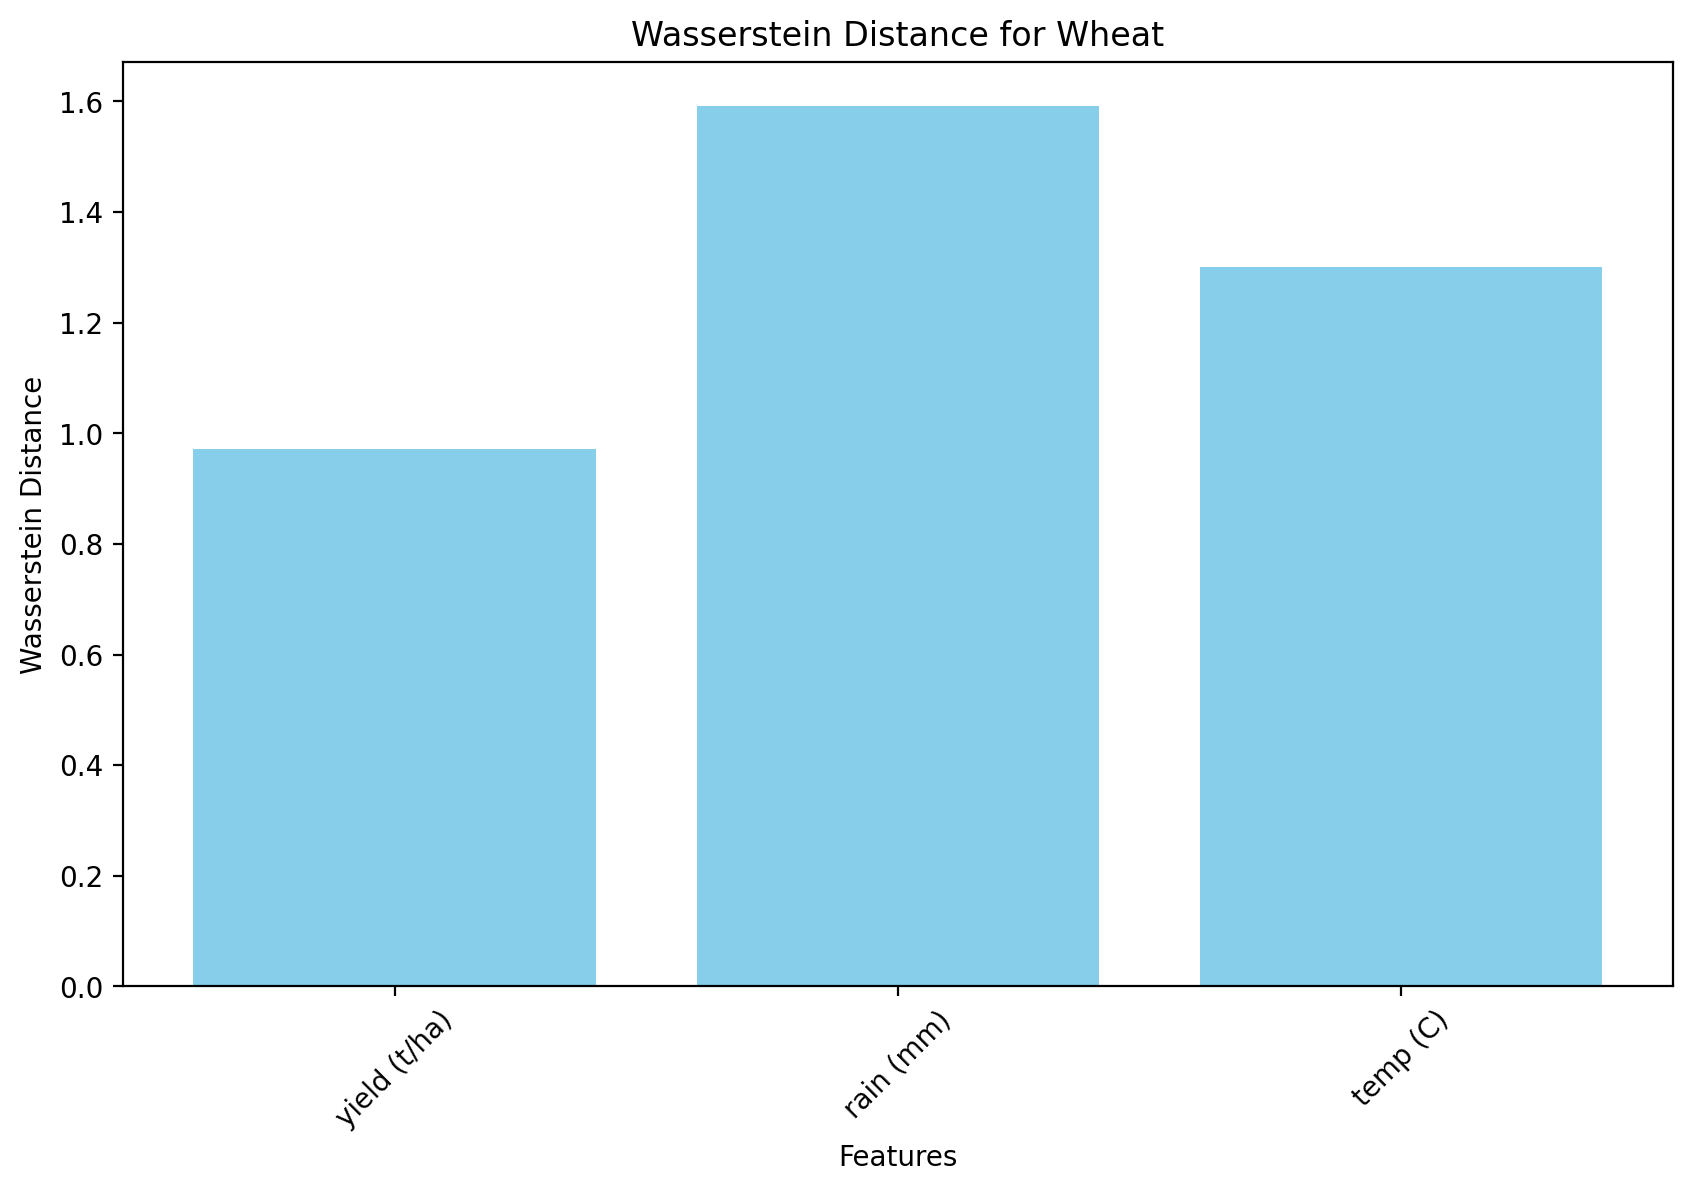
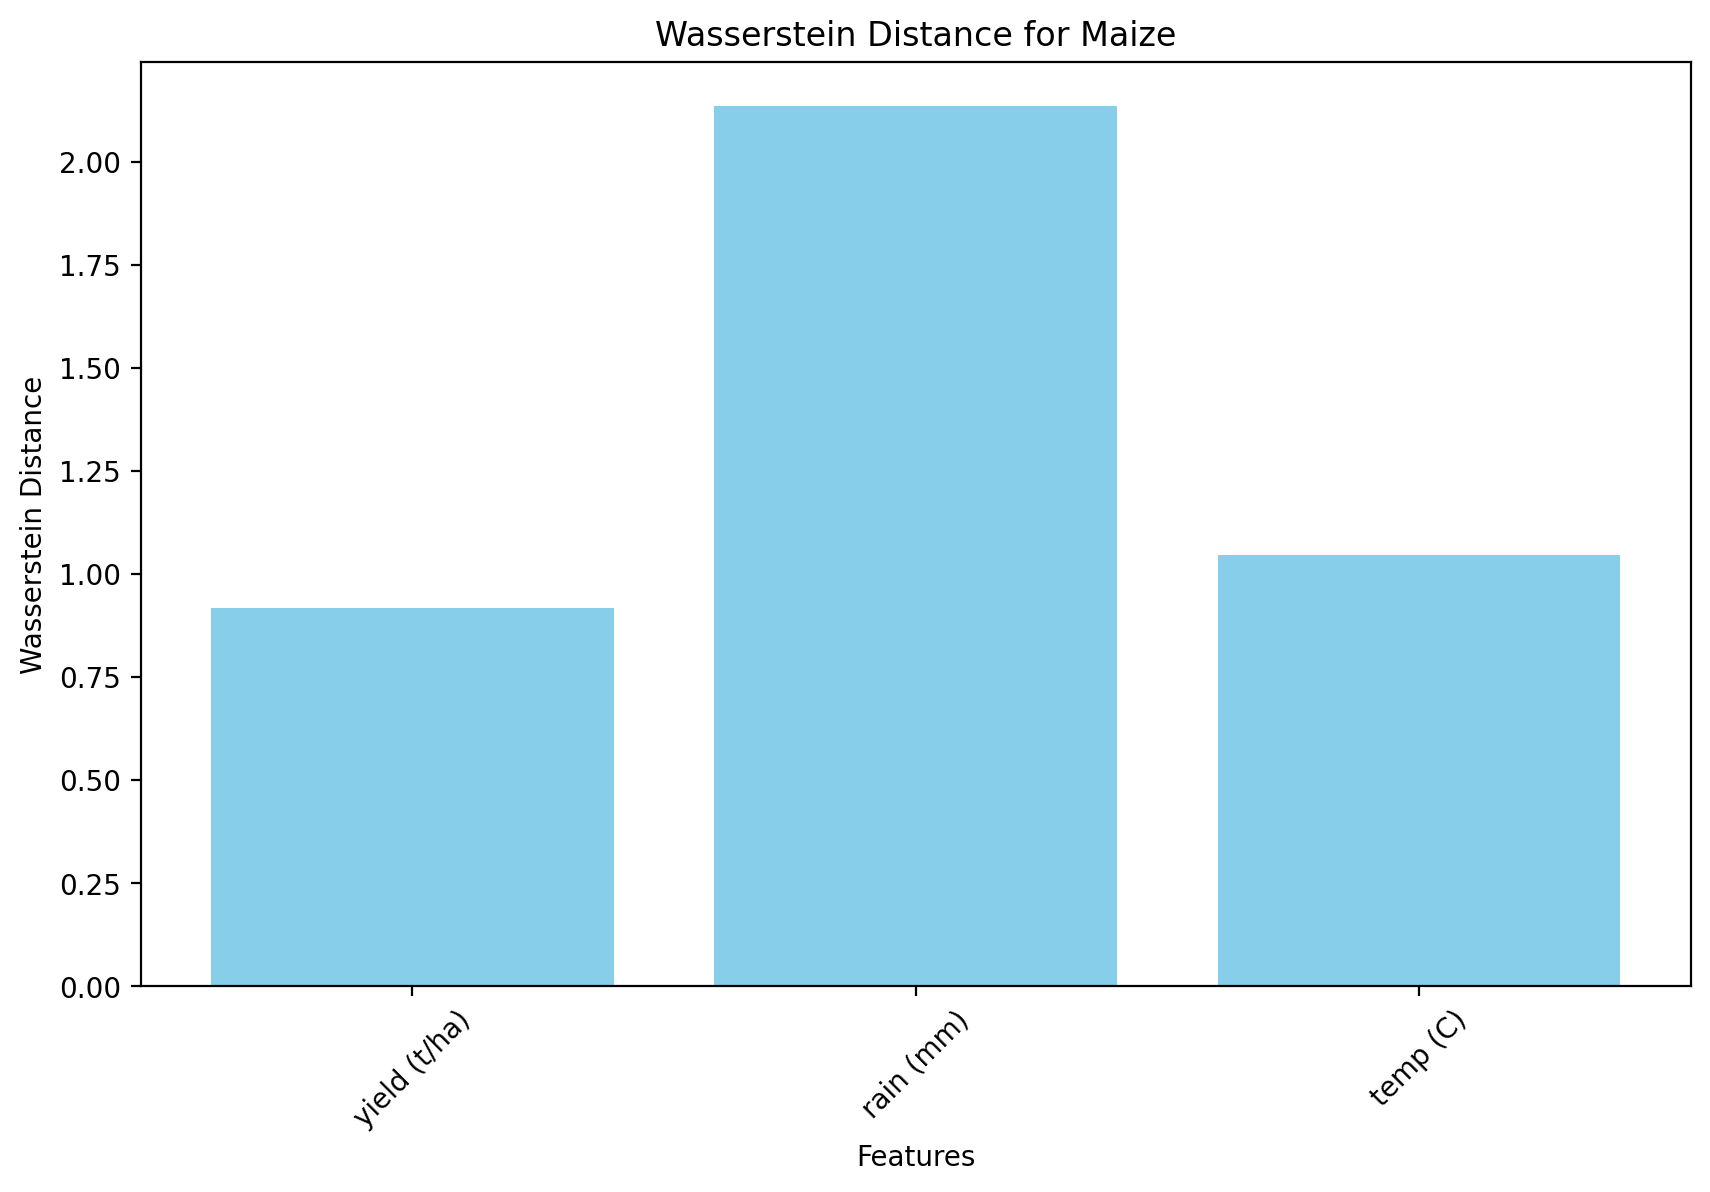
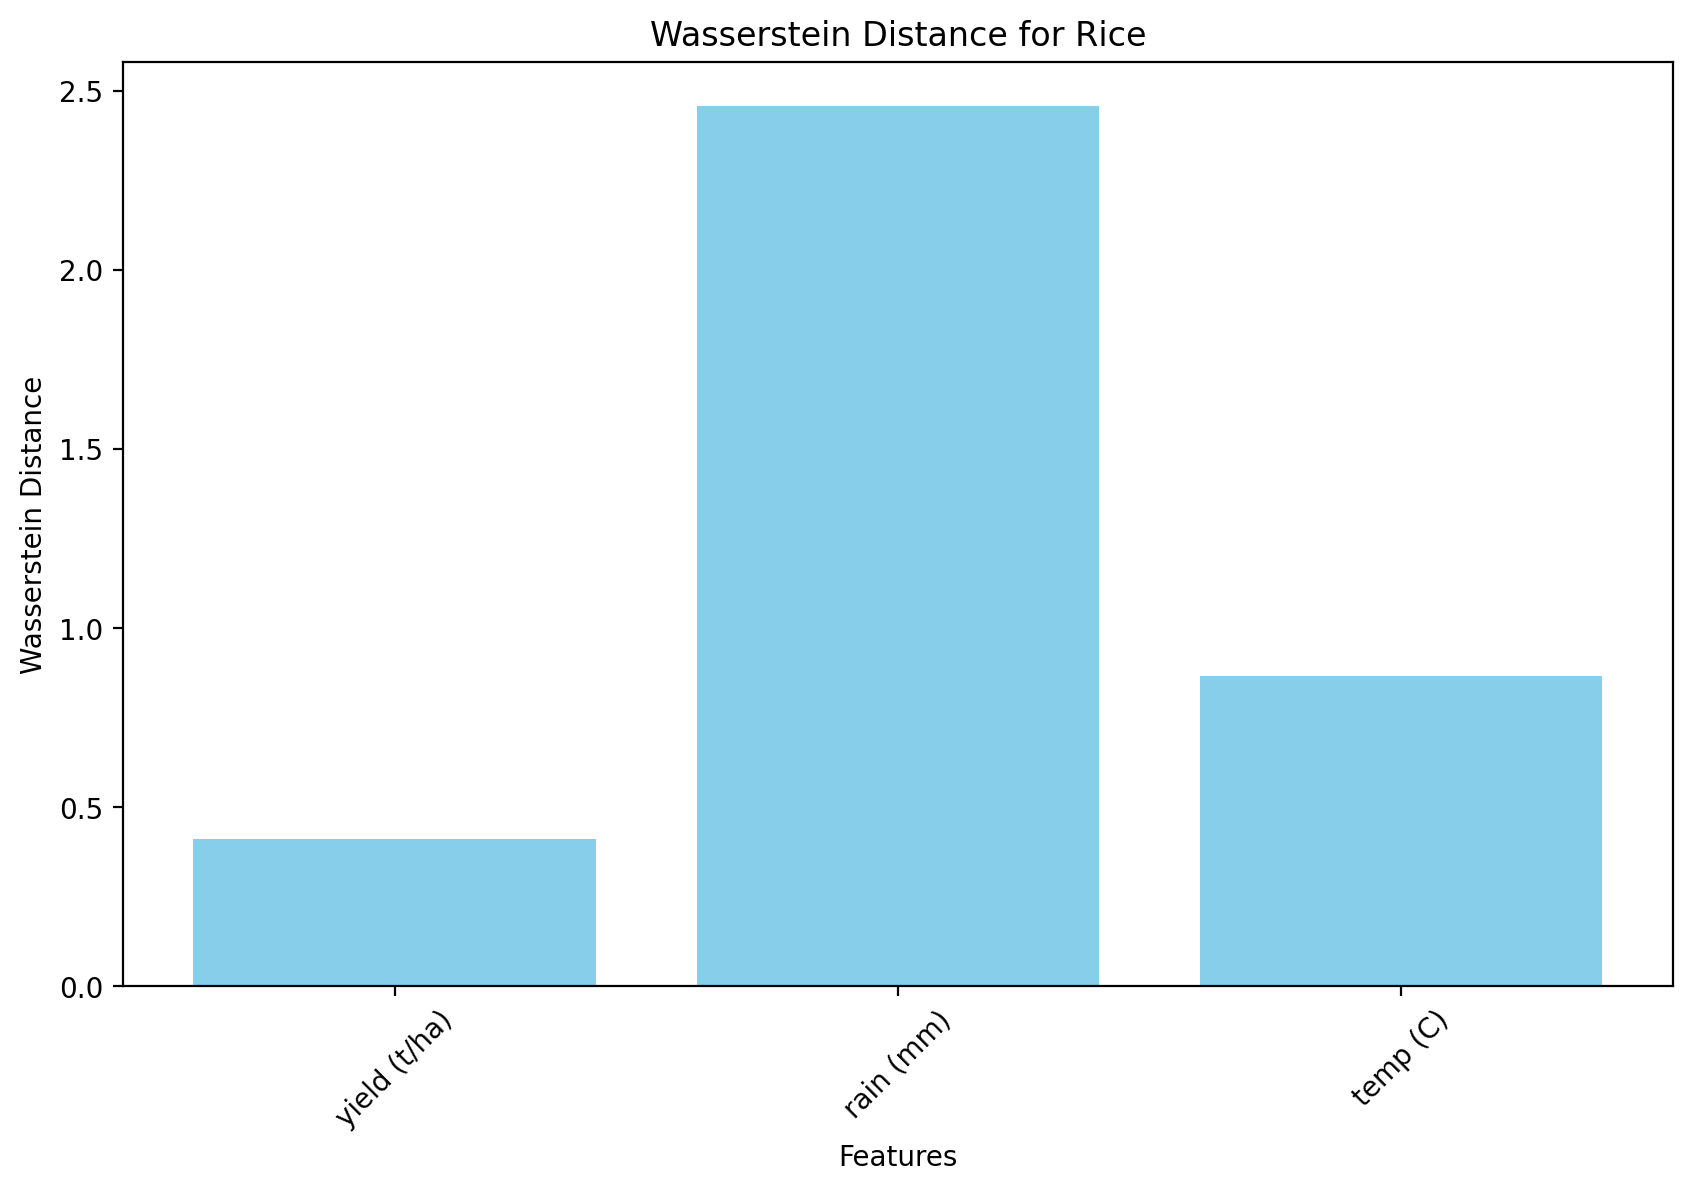
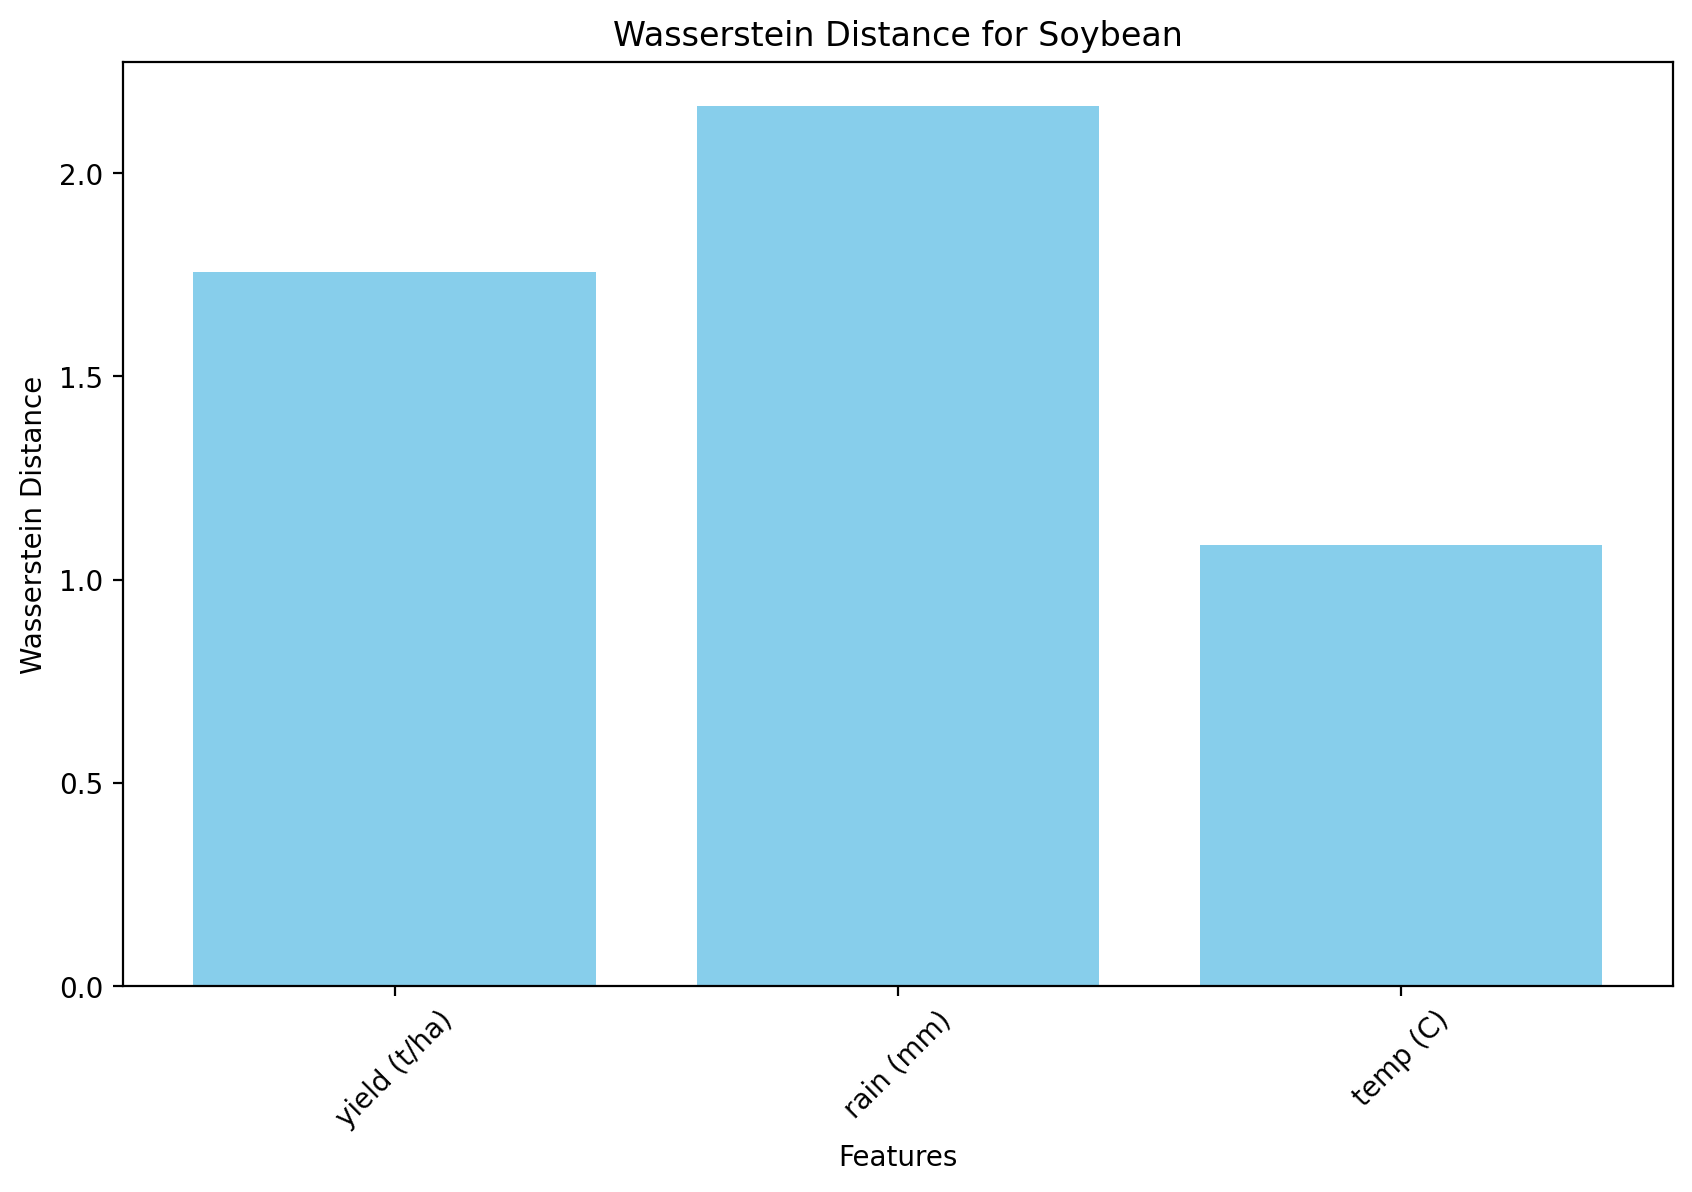

In [68]:
common_real = ["yield (t/ha)", "rain (mm)", "temp (C)"]
common_synth = ["yield (t/ha)", "rain (mm)", "temp (C)"]

pertinence_df = generate_pertinence_report(yield_df, crop_yield, common_real, common_synth, threshold_std=2.0)
pertinence_df.display()

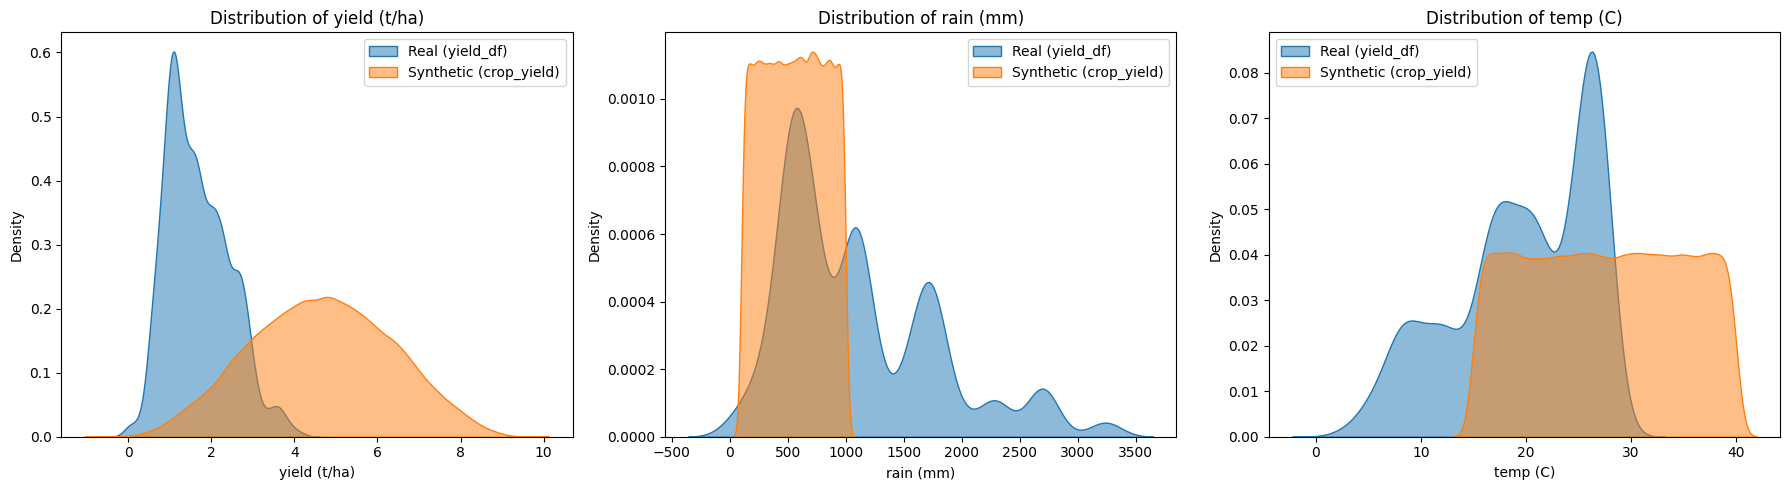

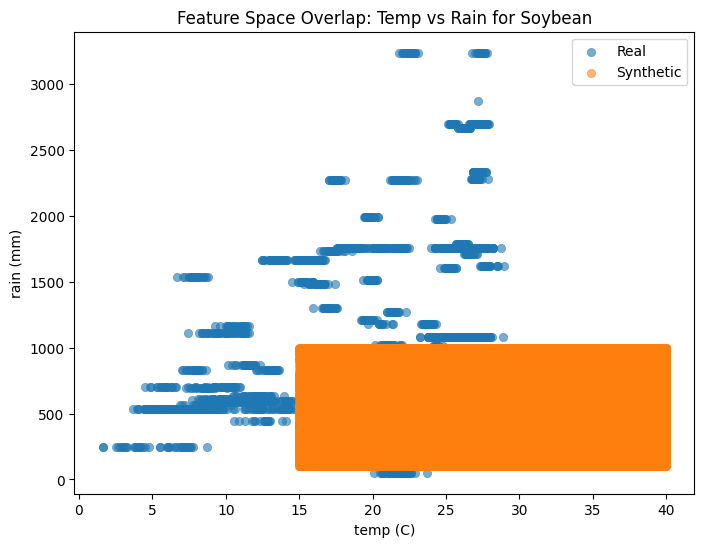

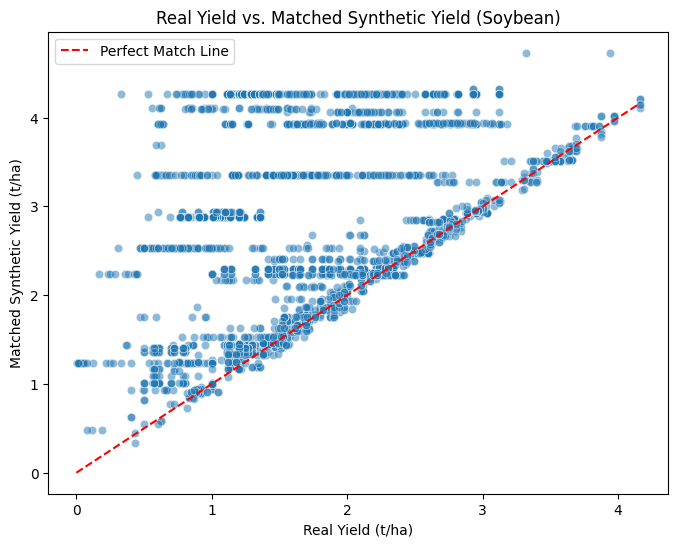

--- Real Soybean Summary Stats ---
       yield (t/ha)    rain (mm)     temp (C)
count   3223.000000  3223.000000  3223.000000
mean       1.673109  1110.774744    19.660279
std        0.760321   687.688761     6.498995
min        0.005000    51.000000     1.610000
25%        1.073400   565.000000    15.670000
50%        1.553300  1083.000000    20.440000
75%        2.207500  1668.000000    25.650000
max        4.160900  3240.000000    29.410000

--- Synthetic Soybean Summary Stats ---
        yield (t/ha)      rain (mm)       temp (C)
count  166349.000000  166349.000000  166349.000000
mean        4.653712     550.474299      27.509328
std         1.696774     259.600033       7.234093
min        -0.595955     100.005750      15.000293
25%         3.424662     325.732987      21.226280
50%         4.657371     551.692898      27.504090
75%         5.881134     774.125259      33.767468
max         9.677596     999.996596      39.999772


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
ITEM = "Soybean"
# 1. Isolate ITEM data from both datasets
real_soy = yield_df[yield_df['item'] == ITEM]
synth_soy = crop_yield[crop_yield['item'] == ITEM]

features_to_check = ['yield (t/ha)', 'rain (mm)', 'temp (C)']

# 2. Plot Density Distributions (Real vs. Synthetic side-by-side)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(features_to_check):
    sns.kdeplot(real_soy[feature], label='Real (yield_df)', fill=True, ax=axs[i], alpha=0.5)
    sns.kdeplot(synth_soy[feature], label='Synthetic (crop_yield)', fill=True, ax=axs[i], alpha=0.5)
    axs[i].set_title(f'Distribution of {feature}')
    axs[i].legend()
plt.tight_layout()
plt.show()

# 3. Scatter Plot: Feature Space Overlap (Rain vs. Temp)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp (C)', y='rain (mm)', data=real_soy, label='Real', alpha=0.6, edgecolor=None)
sns.scatterplot(x='temp (C)', y='rain (mm)', data=synth_soy, label='Synthetic', alpha=0.6, edgecolor=None)
plt.title(f'Feature Space Overlap: Temp vs Rain for {ITEM}')
plt.legend()
plt.show()

# 4. Investigate the KNN Matches Directly
# Let's reuse your function specifically for ITEM to see the real vs matched synthetic yield
ITEM_matches = get_nearest_crop_neighbors(yield_df, crop_yield, ITEM, features_to_check)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='yield (t/ha)', y='yield (t/ha)_synth', data=ITEM_matches, alpha=0.5)
plt.plot([0, max(ITEM_matches['yield (t/ha)'])], [0, max(ITEM_matches['yield (t/ha)'])], 
         color='red', linestyle='--', label='Perfect Match Line')
plt.title(f'Real Yield vs. Matched Synthetic Yield ({ITEM})')
plt.xlabel('Real Yield (t/ha)')
plt.ylabel('Matched Synthetic Yield (t/ha)')
plt.legend()
plt.show()

# 5. Print Summary Statistics to spot hard limits
print(f"--- Real {ITEM} Summary Stats ---")
print(real_soy[features_to_check].describe())
print(f"\n--- Synthetic {ITEM} Summary Stats ---")
print(synth_soy[features_to_check].describe())

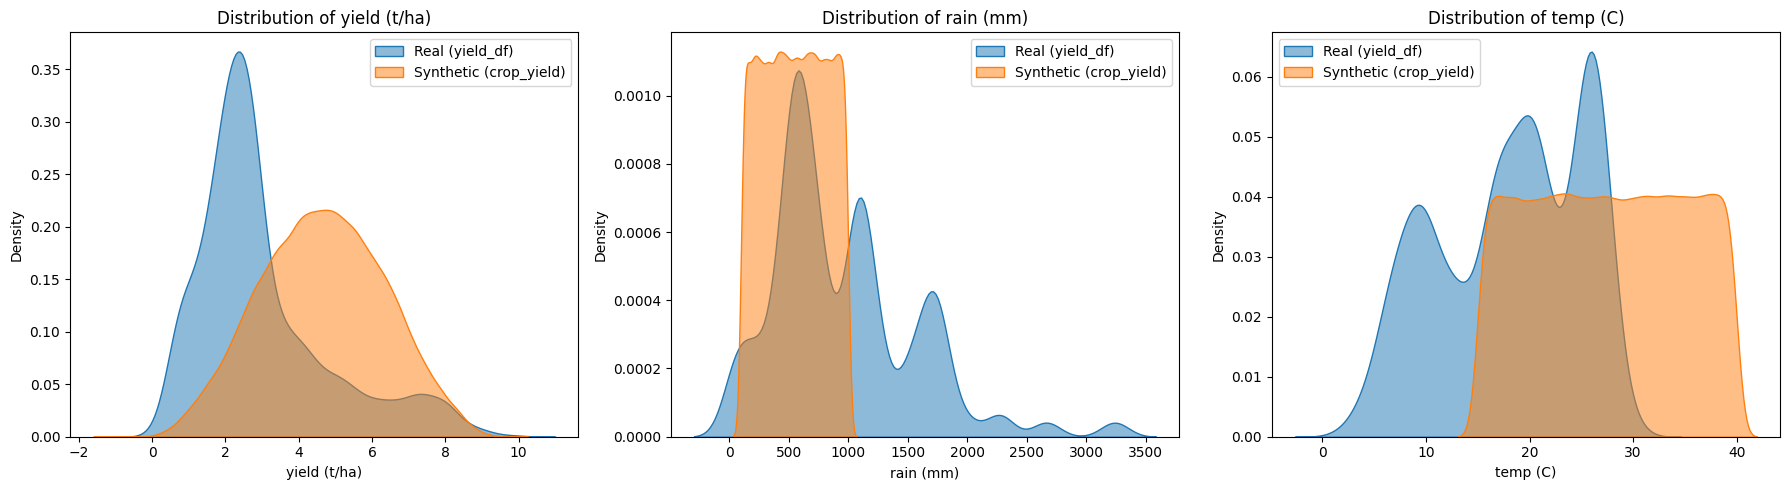

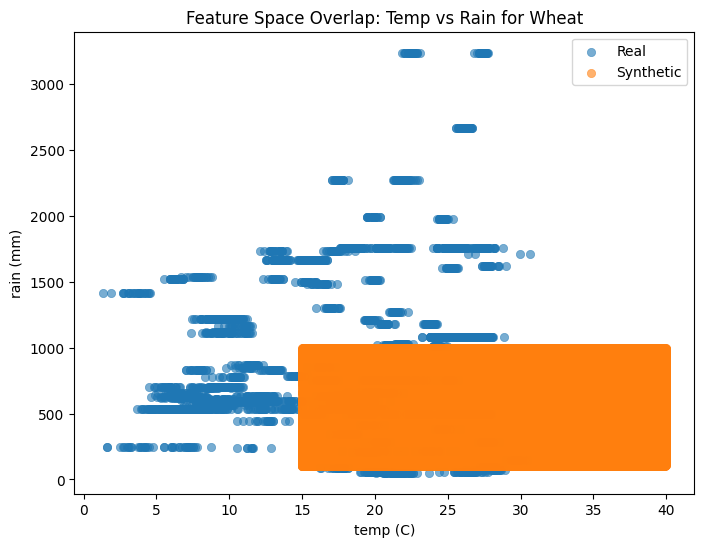

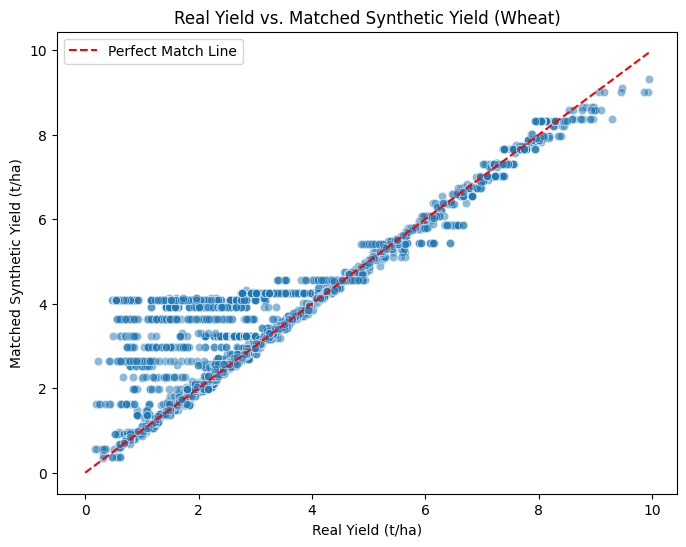

--- Real Wheat Summary Stats ---
       yield (t/ha)    rain (mm)     temp (C)
count   3857.000000  3857.000000  3857.000000
mean       3.011627   957.285974    18.131623
std        1.838788   602.536940     6.904207
min        0.170600    51.000000     1.300000
25%        1.869600   537.000000    12.160000
50%        2.549700   758.000000    19.100000
75%        3.644700  1220.000000    24.720000
max        9.938700  3240.000000    30.650000

--- Synthetic Wheat Summary Stats ---
        yield (t/ha)      rain (mm)       temp (C)
count  166673.000000  166673.000000  166673.000000
mean        4.652740     550.248678      27.515932
std         1.694823     259.770198       7.218651
min        -1.147613     100.013224      15.000068
25%         3.425895     325.718159      21.289670
50%         4.655529     550.472271      27.509499
75%         5.880076     775.122542      33.768426
max         9.802534     999.985356      39.999997


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
ITEM = "Wheat"
# 1. Isolate ITEM data from both datasets
real_soy = yield_df[yield_df['item'] == ITEM]
synth_soy = crop_yield[crop_yield['item'] == ITEM]

features_to_check = ['yield (t/ha)', 'rain (mm)', 'temp (C)']

# 2. Plot Density Distributions (Real vs. Synthetic side-by-side)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(features_to_check):
    sns.kdeplot(real_soy[feature], label='Real (yield_df)', fill=True, ax=axs[i], alpha=0.5)
    sns.kdeplot(synth_soy[feature], label='Synthetic (crop_yield)', fill=True, ax=axs[i], alpha=0.5)
    axs[i].set_title(f'Distribution of {feature}')
    axs[i].legend()
plt.tight_layout()
plt.show()

# 3. Scatter Plot: Feature Space Overlap (Rain vs. Temp)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp (C)', y='rain (mm)', data=real_soy, label='Real', alpha=0.6, edgecolor=None)
sns.scatterplot(x='temp (C)', y='rain (mm)', data=synth_soy, label='Synthetic', alpha=0.6, edgecolor=None)
plt.title(f'Feature Space Overlap: Temp vs Rain for {ITEM}')
plt.legend()
plt.show()

# 4. Investigate the KNN Matches Directly
# Let's reuse your function specifically for ITEM to see the real vs matched synthetic yield
ITEM_matches = get_nearest_crop_neighbors(yield_df, crop_yield, ITEM, features_to_check)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='yield (t/ha)', y='yield (t/ha)_synth', data=ITEM_matches, alpha=0.5)
plt.plot([0, max(ITEM_matches['yield (t/ha)'])], [0, max(ITEM_matches['yield (t/ha)'])], 
         color='red', linestyle='--', label='Perfect Match Line')
plt.title(f'Real Yield vs. Matched Synthetic Yield ({ITEM})')
plt.xlabel('Real Yield (t/ha)')
plt.ylabel('Matched Synthetic Yield (t/ha)')
plt.legend()
plt.show()

# 5. Print Summary Statistics to spot hard limits
print(f"--- Real {ITEM} Summary Stats ---")
print(real_soy[features_to_check].describe())
print(f"\n--- Synthetic {ITEM} Summary Stats ---")
print(synth_soy[features_to_check].describe())

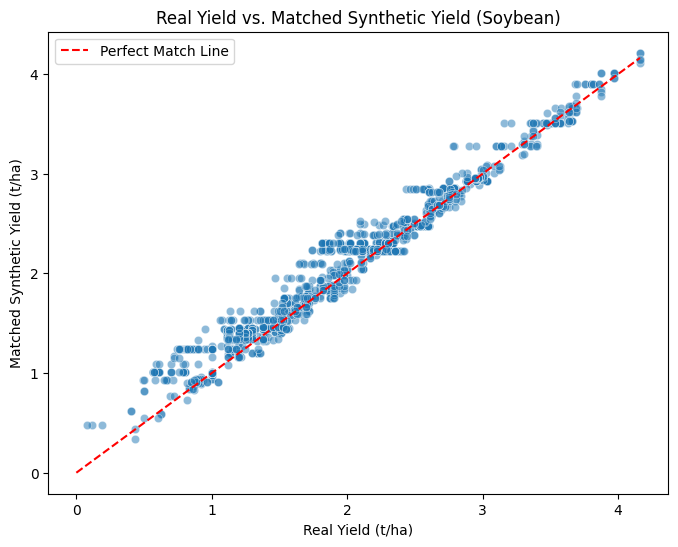

Original samples: 3223
Cleaned samples: 1286
Retention rate: 39.90%


In [71]:
ITEM = "Soybean"
ITEM_matches = get_nearest_crop_neighbors(yield_df, crop_yield, ITEM, features_to_check)
# 1. Define your tolerance (e.g., 0.5 t/ha)
# Adjust this based on how much data you are willing to lose
tolerance = 0.5 

# 2. Calculate the absolute difference
ITEM_matches['yield_error'] = (ITEM_matches['yield (t/ha)'] - ITEM_matches['yield (t/ha)_synth']).abs()

# 3. Filter the dataset
cleaned_matches = ITEM_matches[ITEM_matches['yield_error'] <= tolerance].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='yield (t/ha)', y='yield (t/ha)_synth', data=cleaned_matches, alpha=0.5)
plt.plot([0, max(cleaned_matches['yield (t/ha)'])], [0, max(cleaned_matches['yield (t/ha)'])], 
         color='red', linestyle='--', label='Perfect Match Line')
plt.title(f'Real Yield vs. Matched Synthetic Yield ({ITEM})')
plt.xlabel('Real Yield (t/ha)')
plt.ylabel('Matched Synthetic Yield (t/ha)')
plt.legend()
plt.show()

# 4. Quick stats to see the impact
original_count = len(ITEM_matches)
cleaned_count = len(cleaned_matches)
percent_kept = (cleaned_count / original_count) * 100

print(f"Original samples: {original_count}")
print(f"Cleaned samples: {cleaned_count}")
print(f"Retention rate: {percent_kept:.2f}%")

**Maize:**

Original samples: 4121

Cleaned samples: 1891

Retention rate: 45.89%


**Wheat:**

Original samples: 3857

Cleaned samples: 2552

Retention rate: 66.17%

**Rice:**

Original samples: 3388

Cleaned samples: 2017

Retention rate: 59.53%


**Soybean:**

Original samples: 3223

Cleaned samples: 1286

Retention rate: 39.90%


In [72]:
top_crops = ["Wheat", "Maize", "Rice"]

real_cols = ["yield (t/ha)", "rain (mm)", "temp (C)", "item", "Year", "pesticides_tonnes", "Area"]
synth_cols = ["Days_to_Harvest", "Irrigation_Used", "Fertilizer_Used", "Soil_Type"] # "Region", "Weather_Condition" dropped because of irrelevance in term of job
common_cols =["yield (t/ha)", "rain (mm)", "temp (C)"]

final_training_dataset = []

for crop in top_crops:
    matches = get_nearest_crop_neighbors(yield_df, crop_yield, crop, common_cols)
    
    # 1. Keep all REAL features
    # 2. Add SYNTHETIC features that aren't in the real set (e.g., Soil, Region)
    # 3. Use ONLY the Real Yield
    selected_data = matches[real_cols + synth_cols]
    
    final_training_dataset.append(selected_data)

# Combine into one clean dataframe
df_train = pd.concat(final_training_dataset).reset_index(drop=True)
df_train.head()

,yield (t/ha),rain (mm),temp (C),item,Year,pesticides_tonnes,Area,Days_to_Harvest,Irrigation_Used,Fertilizer_Used,Soil_Type
0,3.0197,1485.0,16.37,Wheat,1990,121.0,Albania,120,False,False,Loam
1,2.0698,1485.0,15.36,Wheat,1991,121.0,Albania,120,False,False,Peaty
2,2.4388,1485.0,16.06,Wheat,1992,121.0,Albania,120,False,False,Peaty
3,2.9976,1485.0,16.05,Wheat,1993,121.0,Albania,120,False,False,Loam
4,2.4745,1485.0,16.96,Wheat,1994,201.0,Albania,120,False,False,Peaty


In [73]:
df_train_ohe = pd.get_dummies(df_train, columns=["Soil_Type", "Area"], drop_first=True)
df_train_ohe.head()

,yield (t/ha),rain (mm),temp (C),item,Year,pesticides_tonnes,Days_to_Harvest,Irrigation_Used,Fertilizer_Used,Soil_Type_Clay,...,Area_Tajikistan,Area_Thailand,Area_Tunisia,Area_Turkey,Area_Uganda,Area_Ukraine,Area_United Kingdom,Area_Uruguay,Area_Zambia,Area_Zimbabwe
0,3.0197,1485.0,16.37,Wheat,1990,121.0,120,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2.0698,1485.0,15.36,Wheat,1991,121.0,120,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2.4388,1485.0,16.06,Wheat,1992,121.0,120,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2.9976,1485.0,16.05,Wheat,1993,121.0,120,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2.4745,1485.0,16.96,Wheat,1994,201.0,120,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [74]:
df_train_ohe.to_csv("../data/processed/knn_merged.csv", index=False)

In [75]:
for c in df_train_ohe.columns:
    print(c, end=" ")

yield (t/ha) rain (mm) temp (C) item Year pesticides_tonnes Days_to_Harvest Irrigation_Used Fertilizer_Used Soil_Type_Clay Soil_Type_Loam Soil_Type_Peaty Soil_Type_Sandy Soil_Type_Silt Area_Algeria Area_Angola Area_Argentina Area_Armenia Area_Australia Area_Austria Area_Azerbaijan Area_Bahamas Area_Bangladesh Area_Belarus Area_Belgium Area_Botswana Area_Brazil Area_Bulgaria Area_Burkina Faso Area_Burundi Area_Cameroon Area_Canada Area_Central African Republic Area_Chile Area_Colombia Area_Croatia Area_Denmark Area_Dominican Republic Area_Ecuador Area_Egypt Area_El Salvador Area_Eritrea Area_Estonia Area_Finland Area_France Area_Germany Area_Ghana Area_Greece Area_Guatemala Area_Guinea Area_Guyana Area_Haiti Area_Honduras Area_Hungary Area_India Area_Indonesia Area_Iraq Area_Ireland Area_Italy Area_Jamaica Area_Japan Area_Kazakhstan Area_Kenya Area_Latvia Area_Lebanon Area_Lesotho Area_Libya Area_Lithuania Area_Madagascar Area_Malawi Area_Malaysia Area_Mali Area_Mauritania Area_Mauritiu

In [76]:
df_train.sample()

,yield (t/ha),rain (mm),temp (C),item,Year,pesticides_tonnes,Area,Days_to_Harvest,Irrigation_Used,Fertilizer_Used,Soil_Type
8209,10.2177,534.0,14.74,Rice,2013,45177.18,Australia,104,True,True,Silt
